# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
display(plans.head())

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
display(users.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
display(usage.head())

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("Tamaño de users:", users.shape)
print("Tamaño de usage:", usage.shape)

plans (2, 8)
Tamaño de users: (4000, 8)
Tamaño de usage: (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [43]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           565
reg_date        40
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.14125
reg_date      0.01000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
    En la tabla users:
    churn_date: 3534 nulos (88.35%)
    city: 469 nulos (11.72%)

    En la tabla usage:
    duration: 22076 nulos (55.19%)
    length: 17896 nulos (44.74%)
    date: 50 nulos (0.12%)
  
- Indica qué harías: ¿imputar, eliminar, ignorar?

    churn_date: Ignorar. El nulo significa que el usuario no ha cancelado su plan.

    city: Imputar con la palabra "Desconocido" para no tener que borrar a esos usuarios.

    duration y length: Imputar con 0. Faltan porque el registro es de una llamada o de internet, no de los dos al mismo tiempo.

    date: Eliminar esas filas. Son solo 50 datos y no afectarán el análisis.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
display(users.describe())

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`: Contiene identificadores únicos de clientes que van desde el número 10000 hasta el 13999. No presenta valores anormales y todo parece estar normal.

- La columna `age`: Presenta un valor mínimo de -999, lo cual es un claro valor inválido o un error de captura. El resto de las edades parecen normales (máximo 79 años), pero ese -999 afecta fuertemente el promedio. 

In [13]:
# explorar columnas numéricas de usage
display(usage.describe())

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`: Contienen números de identificación que están en orden y dentro de los rangos correctos. El `id` va del 1 al 40000 (coincide con el total de filas) y el `user_id` va del 10000 al 13999, coincidiendo perfectamente con los identificadores de clientes en la tabla users. No hay valores extraños.

- Las columnas `duration` y `length`: No presentan valores negativos ni valores inválidos. El valor mínimo para ambas es 0, lo cual es lógico para el negocio (llamadas de cero segundos o nulo consumo de datos), y sus máximos (120 y 1490 respectivamente) son valores normales.


In [14]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for columna in columnas_user:
    print(users[columna].value_counts())

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city`: La mayoría de los datos están bien, pero encontramos 96 registros marcados con un signo ?. Es un valor inválido que indica un error al registrar la ciudad y debe ser corregido o tratado.

- La columna `plan`: Todo está correcto. Solo existen dos categorías, Basico y Premium, tal como debería ser.

In [15]:

# explorar columna categórica de usage
usage['type'].value_counts()


text    22092
call    17908
Name: type, dtype: int64

- La columna `type`: Contiene únicamente las categorías text y call. Los datos son consistentes y no presentan valores inválidos ni errores de formato, por lo que no requieren ninguna corrección.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

En la columna age de la tabla users: Se encontró un valor mínimo de -999.

En la columna city de la tabla users: Se encontraron 96 registros marcados con un signo ?.

- ¿Qué acción tomarías?

Para age: Como el valor -999 es un error, lo reemplazaré por el valor promedio o mediano de la edad, o lo trataré como un valor nulo para no dañar el análisis.

Para city: Dado que el signo ? no aporta información de cual es la ciudad, reemplazaré estos registros por la etiqueta "Desconocido" para mantener la integridad de los datos sin perder las filas correspondientes.

Resto de columnas: Las columnas duration, length, id, user_id, plan y type no presentan valores inválidos ni errores de captura, por lo que no requieren acciones de limpieza.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
# Verificar el cambio
print(users['reg_date'].dtype)

datetime64[ns]


In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
# Verificar el cambio
print(usage['date'].dtype)

datetime64[ns]


In [18]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts())


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`:Se encontraron 40 registros con fecha del año 2026. Como el estudio llega hasta 2024, estos datos son errores de captura ("fechas futuras").

In [19]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts())

2024.0    39950
Name: date, dtype: int64


En `date`: No es necesaria ninguna acción, ya que los datos son consistentes y sirven como base confiable para el estudio.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) Sí, en la columna reg_date de la tabla users aparecen 40 registros del año 2026, los cuales están fuera del rango histórico (límite 2024).
  
- ¿Qué harías con ellas? Filtrar o eliminar esos 40 registros para evitar errores en el análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
print(users['city'].isna().sum())
print(users['city'].value_counts(dropna=False))

565
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [22]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].isna().sum())


40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.isna().groupby(usage['type'])['duration'].mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.isna().groupby(usage['type'])['length'].mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Diagnóstico de nulos en `duration` y `length`:

Los datos faltantes no son un error, sino que dependen del tipo de servicio (type):

- Las llamadas (call) no tienen longitud, por eso falta el dato en length.
- Los mensajes (text) no tienen duración, por eso falta el dato en duration.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'cant_mensajes': 'cant_mensajes',
    'cant_llamadas': 'cant_llamadas',
    'cant_minutos_llamada': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

# Rellenar con 0 los valores nulos generados para usuarios sin actividad
cols_to_fill = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[cols_to_fill] = user_profile[cols_to_fill].fillna(0)

# Observar el resultado
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01



### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.


In [28]:
# Resumen estadístico de las columnas numéricas
# Inclusión de las columnas de edad y las métricas de uso que calculamos
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print(user_profile[columnas_numericas].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    4000.000000    4000.000000           4000.000000
mean     48.136000       5.523000       4.477000             23.311225
std      17.689919       2.359738       2.145139             18.169564
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.107500
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.412500
max      79.000000      17.000000      15.000000            155.690000


In [29]:
# Distribución porcentual del tipo de plan
distribucion_plan = user_profile['plan'].value_counts(normalize=True) * 100
print(distribucion_plan)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---


## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas


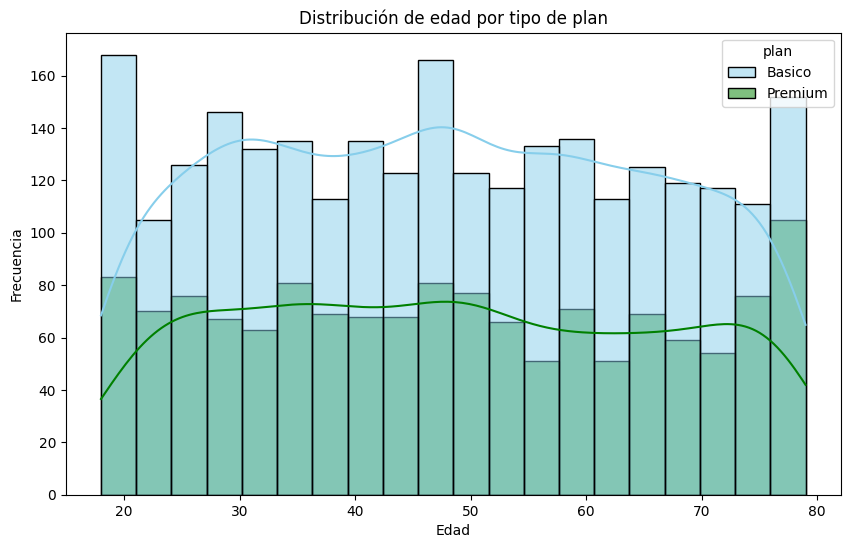

In [30]:

# Histograma para visualizar la edad (age)
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True, bins=20)
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insight:

- Insight sobre la edad: "La distribución de la edad es uniforme y centrada en un promedio de 48 años, cubriendo un rango amplio de usuarios desde los 18 hasta los 79 años. Esto indica que el servicio cuenta con una base de clientes demográficamente diversa y que no existe una tendencia de edad predominante que diferencie a los usuarios de los planes Básico y Premium."

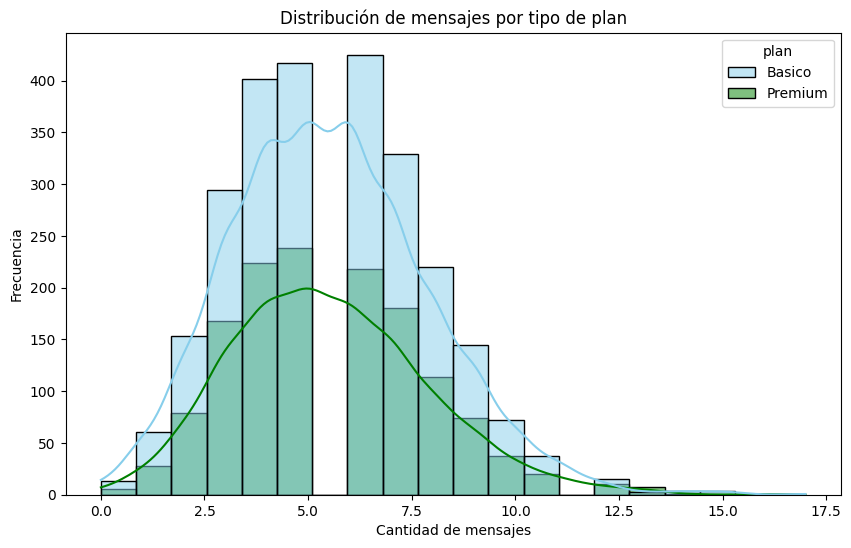

In [31]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True, bins=20)
plt.title('Distribución de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: Presenta un sesgo a la derecha. Esto significa que la mayor parte de los usuarios envía una cantidad baja de mensajes (la "montaña" de datos está a la izquierda), mientras que la cantidad de usuarios disminuye a medida que aumenta el uso de mensajes (la "cola" larga a la derecha).

- Patrón: No se observa una diferencia marcada entre los planes; tanto los usuarios de plan Básico como los de Premium tienen un comportamiento similar de consumo moderado en cuanto a mensajería.

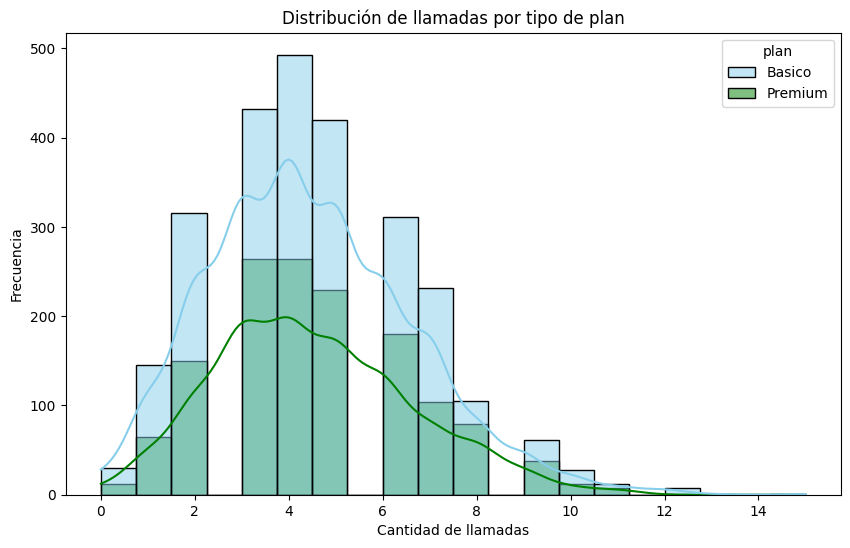

In [32]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True, bins=20)
plt.title('Distribución de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: Al igual que con los mensajes, esta variable presenta un sesgo a la derecha. La mayor parte de tus usuarios realiza un número bajo de llamadas (el pico está concentrado en la parte izquierda), mientras que muy pocos usuarios realizan una cantidad alta de llamadas.

- Patrón: No se aprecia una diferencia significativa en el comportamiento entre los planes Básico y Premium; ambos muestran una tendencia similar donde el consumo moderado es la norma.

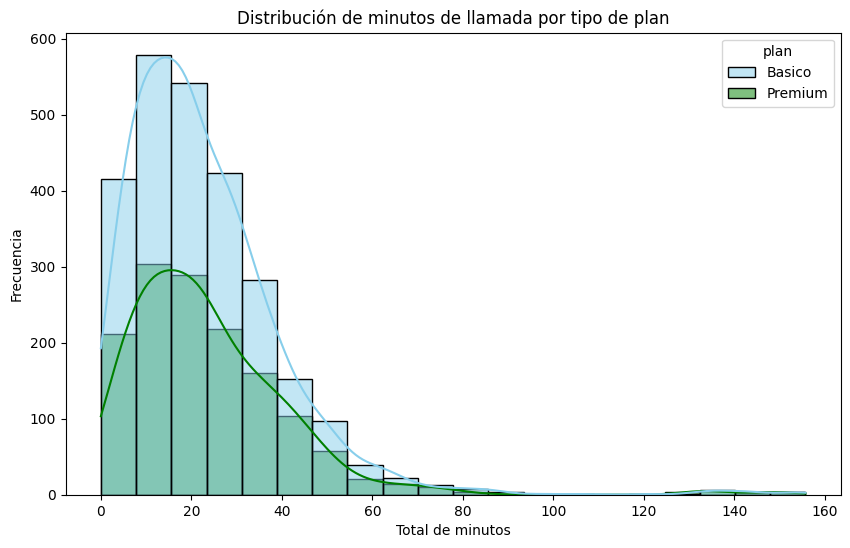

In [33]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True, bins=20)
plt.title('Distribución de minutos de llamada por tipo de plan')
plt.xlabel('Total de minutos')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 

- Distribución: Presenta un sesgo marcado hacia la derecha. Esto indica que la gran mayoría de los usuarios se concentra en un consumo bajo de minutos, mientras que la curva se extiende hacia valores más altos.

- Patrón: Esta gráfica evidencia claramente la existencia de usuarios con consumo muy alto (personas que hablan significativamente más que el resto). Estos casos ocurren en ambos planes y son los responsables de los valores extremos que se observan al final de la gráfica.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

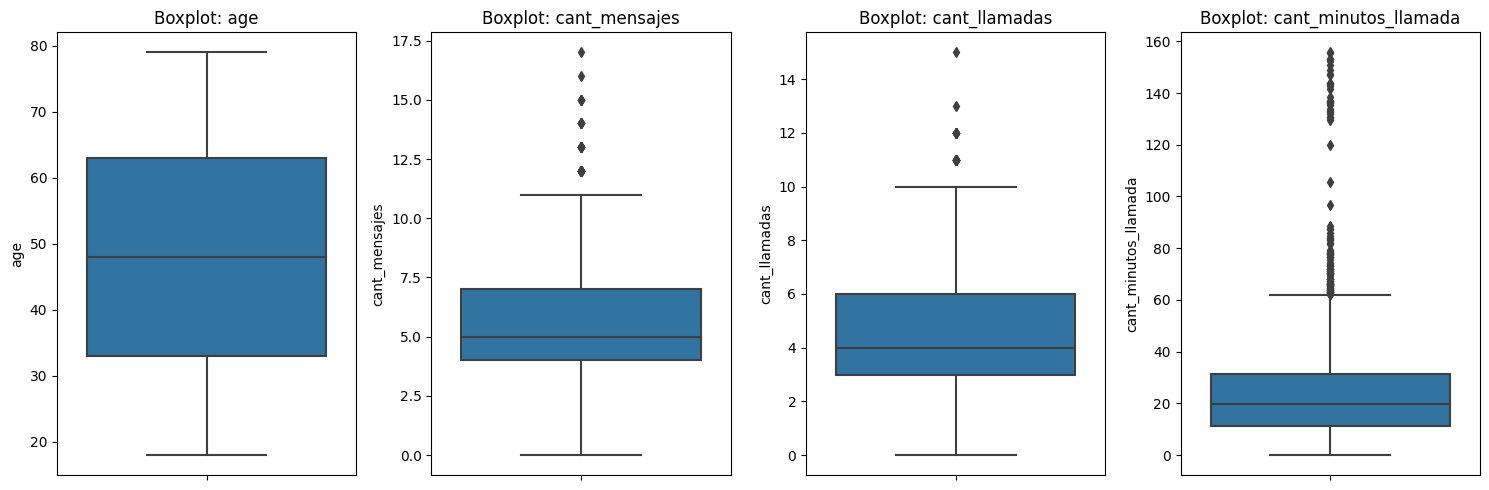

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Creación del bucle para generar los 4 boxplots
plt.figure(figsize=(15, 5))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(data=user_profile, y=col)
    plt.title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

💡Insights: 
- Age: No presenta valores extremos (outliers). La distribución es uniforme y todas las edades se encuentran dentro de un rango esperado y coherente.

- cant_mensajes: Sí presenta valores extremos. Existen usuarios con un consumo muy alto que envían una cantidad de mensajes significativamente mayor al resto.

- cant_llamadas: Sí presenta valores extremos. Se observa un pequeño grupo de usuarios que realiza una cantidad de llamadas muy superior al comportamiento habitual de la mayoría.

- cant_minutos_llamada: Sí presenta valores extremos. Al igual que en las llamadas, son detectados usuarios con un consumo muy alto de minutos que se alejan de la media, confirmando que son casos aislados de uso intensivo.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Bucle para calcular los límites y contar los usuarios extremos
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Como los datos están sesgados a la derecha, solo se necesita el límite superior
    limite_superior = Q3 + 1.5 * IQR
    
    # Contar cuántos usuarios superan ese límite
    cantidad_outliers = len(user_profile[user_profile[col] > limite_superior])
    
    print(f"Columna {col}:")
    print(f"  - Límite superior: {limite_superior:.2f}")
    print(f"  - Usuarios con consumo muy alto: {cantidad_outliers}")
    print("-" * 30)


Columna cant_mensajes:
  - Límite superior: 11.50
  - Usuarios con consumo muy alto: 46
------------------------------
Columna cant_llamadas:
  - Límite superior: 10.50
  - Usuarios con consumo muy alto: 30
------------------------------
Columna cant_minutos_llamada:
  - Límite superior: 61.87
  - Usuarios con consumo muy alto: 109
------------------------------


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
print(user_profile[columnas_limites].describe().loc[['max']])

     cant_mensajes  cant_llamadas  cant_minutos_llamada
max           17.0           15.0                155.69


💡Insights: Decisión sobre Valores Extremos (Outliers)

Para las tres variables analizadas, la decisión técnica ha sido mantener los valores extremos en el conjunto de datos por las siguientes razones:

- cant_mensajes:

Decisión: Mantener.

¿Por qué? Aunque el límite estadístico es de 11.5 mensajes, el valor máximo real (17) es perfectamente coherente para un usuario activo. No hay evidencia de errores en la captura de datos, por lo que eliminar estos registros distorsionaría el comportamiento real de nuestros clientes.

- cant_llamadas:

Decisión: Mantener.

¿Por qué? El valor máximo observado es de 15 llamadas, frente a un límite estadístico de 10.5. Al ser un valor dentro de un rango de uso cotidiano y lógico, representa una muestra válida de usuarios con un nivel de actividad superior al promedio, cuya eliminación sesgaría el análisis del consumo real.

- cant_minutos_llamada:

Decisión: Mantener.

¿Por qué? Esta variable presenta la mayor diferencia entre el límite estadístico (61.87) y el máximo real (155.69). Sin embargo, un consumo de 155 minutos sigue siendo una cifra lógica y habitual en telecomunicaciones. Estos registros son fundamentales para entender a los usuarios con consumo muy alto, quienes son un segmento clave para el análisis de rentabilidad de la compañía.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

# Crear la columna 'grupo_uso' aplicando la función a cada fila (axis=1)
user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

# Verificar la distribución
print(user_profile['grupo_uso'].value_counts())

Uso medio    2943
Bajo uso      779
Alto uso      278
Name: grupo_uso, dtype: int64


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

Text(0, 0.5, 'Cantidad de usuarios')

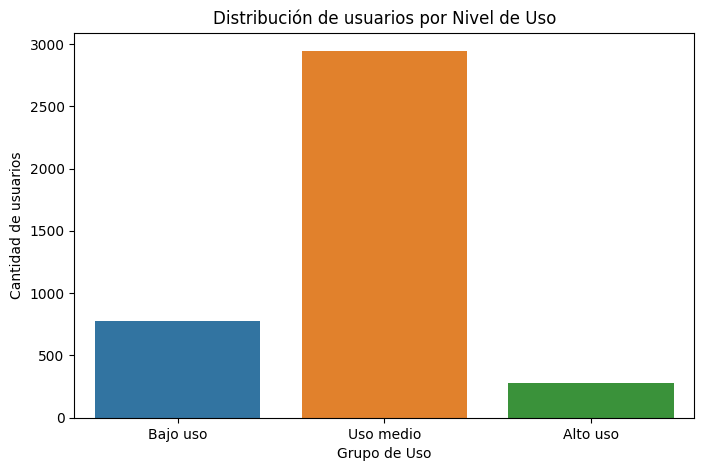

In [41]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'])

plt.title('Distribución de usuarios por Nivel de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de usuarios')

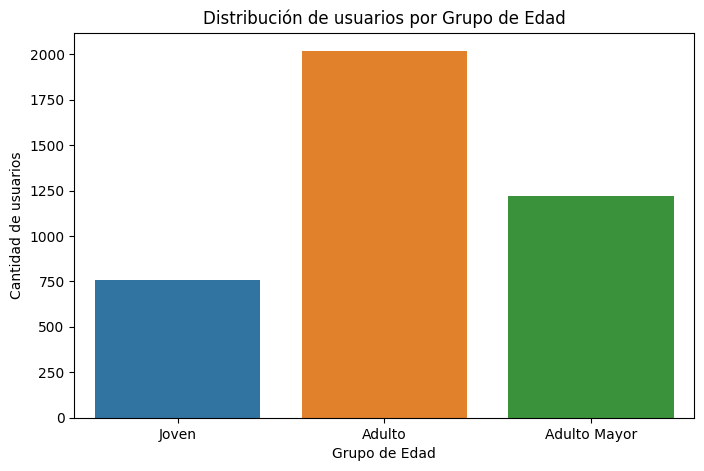

In [42]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'])

plt.title('Distribución de usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---

## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- En la tabla de usuarios (users), churn_date registró 3,534 nulos (88.35%) y city presentó 469 nulos (11.72%).

- En la tabla de uso (usage), encontramos nulos en duration con 22,076 (55.19%), length con 17,896 (44.74%) y date con 50 (0.12%).

    **Acciones y decisiones tomadas:**

- churn_date (>80%): Se decidió ignorar, ya que los nulos representan lógicamente a los usuarios que siguen activos y no han cancelado el plan.

- city (entre 5% y 30%): Se optó por imputar con la categoría "Desconocido" para conservar a los usuarios y evitar perder la muestra.

- duration y length (rangos altos): Se imputaron con 0, dado que corresponden a la naturaleza mixta de los registros (llamadas o internet, donde no aplican ambas métricas de forma simultánea).

- date (<5%): Se decidió eliminar las 50 filas afectadas al representar un porcentaje mínimo que no altera el análisis global.

    **Anomalías temporales en los registros:**

Se detectaron registros con fechas en el año 2026 en la columna de fechas de registro (reg_date). Esto representaba un error de consistencia temporal en los datos que requirió revisión o filtrado para evitar distorsiones en el análisis histórico de los clientes.

🔍 **Segmentos por Edad**

- Distribución de los segmentos:

La base de usuarios se dividió en tres grupos principales: Adultos, que representan el grupo mayoritario con 2,018 usuarios (51.1%); Adultos Mayores, con 1,222 usuarios (30.9%); y por último el segmento de Jóvenes, con 760 usuarios (18.0%).

- Comportamiento y características:

Al analizar la participación por edades, se observa que más del 82% de la base de clientes de ConnectaTel se concentra en la población madura (Adultos y Adultos Mayores). Esto indica que la oferta actual atrae de manera natural a un público con necesidades más establecidas, mientras que el segmento juvenil mantiene una participación minoritaria pero relevante como mercado potencial de expansión. 

📊 **Segmentos por Nivel de Uso**

- Distribución de los segmentos:

El análisis del comportamiento de consumo muestra una marcada concentración en el segmento de Uso medio, el cual agrupa a 2,943 usuarios (74.5% del total). Le sigue el segmento de Bajo uso con 779 usuarios (18.5%) y, por último, el segmento de Alto uso con apenas 278 usuarios (7.0%).

Comportamiento y patrones:

La gran mayoría de los clientes de ConnectaTel mantienen un consumo moderado y predecible del servicio. La baja presencia del segmento de alto consumo indica que los usuarios intensivos funcionan como un nicho específico, mientras que el volumen considerable de usuarios de bajo y medio uso representa una oportunidad clave para estudiar estrategias de fidelización o incentivos que incrementen su actividad.

➡️ Esto sugiere que:

- Consistencia y estabilidad en el núcleo del negocio: El hecho de que más del 74% de los usuarios tengan un "Uso medio" y que más del 80% pertenezcan a los segmentos de "Adultos" y "Adultos Mayores" indica que ConnectaTel cuenta con una base de clientes madura, estable y con un comportamiento de consumo muy predecible.

- Riesgo y oportunidad en la segmentación: Modificar bruscamente la oferta o los precios actuales podría poner en riesgo a ese grupo del 74.5% de usuarios de uso medio. Sin embargo, también revela una oportunidad desatendida: los segmentos de "Bajo uso" (18.5%) y los "Jóvenes" (18.0%) están pidiendo a gritos estrategias focalizadas para elevar su compromiso o atraer nuevas generaciones que diversifiquen la cartera de clientes lo que ayudaria mucho a la estabilidad futura de la empresa.

💡 **Recomendaciones**

- Proteger y estabilizar el segmento principal: Al ser el grupo de "Adultos" (51.1%) y de "Uso medio" (74.5%) el núcleo de la compañía, cualquier cambio en la estructura de los planes debe evaluarse con cautela para no afectar la retención de este sector que sostiene la estabilidad operativa.

- Estrategias para incentivar el uso: Diseñar campañas o incentivos orientados a los usuarios de Bajo uso (18.5%) para estimular su actividad en la plataforma y elevar gradualmente su nivel de consumo hacia el promedio de la compañía.

- Fidelización del segmento de alto rendimiento: Monitorear y cuidar al segmento de Alto uso (7.0%). Aunque numéricamente son minoría, representan un volumen importante de consumo que aporta valor al comportamiento general de la base.

- Captación de nuevos mercados: Desarrollar propuestas enfocadas en el segmento Joven (18.0%), adaptadas a sus patrones de consumo detectados, para diversificar la base de clientes y reducir la dependencia de los grupos demográficos maduros.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto:
https://github.com/Isabel-Naranjo/connectatel-data-analysis 